<font color='magenta'> 核心函数部分的 TensorFlow 2.x (Python 3.10 + 3060 GPU) 完整适配代码。替换内容：（彻底去除 placeholder 和 session）

## <font color='lightgreen'>TensorFlow Tutorial </font>

Welcome to this week's programming assignment. Until now, you've always used numpy to build neural networks. Now we will step you through a deep learning framework that will allow you to build neural networks more easily. Machine learning frameworks like <font color='magenta'> TensorFlow, PaddlePaddle, Torch, Caffe, Keras</font>, and many others can speed up your machine learning development significantly. All of these frameworks also have a lot of documentation, which you should feel free to read. In this assignment, you will learn to do the following in TensorFlow: 

- Initialize variables 
- Implement activation functions 
- Implement loss functions 
- Train algorithms 
- Implement a Neural Network

Programing frameworks can not only shorten your coding time, but sometimes also perform optimizations that speed up your code. 

## <font color='lightgreen'>Updates</font>

#### If you were working on the notebook before this update...
* The current notebook is version "v3b".

#### List of updates
* forward_propagation instruction now says 'A1' instead of 'a1' in the formula for Z2;  
  and are updated to say 'A2' instead of 'Z2' in the formula for Z3.
* in the model function, the x axis of the plot now says  <font color='yellow'> "iterations (per fives)"  </font>  instead of iterations(per tens)
* In the linear_function, comments remind students to create the variables in the order suggested by the starter code.  The comments are updated to reflect this order.
* The test of the cost function now creates the logits without passing them through a sigmoid function (since the cost function will include the sigmoid in the built-in tensorflow function).
* Updated print statements and 'expected output that are used to check functions, for easier visual comparison.


## 1 - Exploring the Tensorflow Library

To start, you will import the library:

Conda 环境中安装 micromamba 是一个非常聪明的策略，因为 micromamba 采用 C++ 编写，不依赖 Python 运行时，在解析依赖（Solving environment）时的速度比原生 Conda 快一个数量级。

In [1]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.python.ops.numpy_ops import np_config

# 开启兼容性，解决 .numpy() 报错
np_config.enable_numpy_behavior()

# 3060 显存优化
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)

from tf_utils import load_dataset, random_mini_batches, convert_to_one_hot, predict
%matplotlib inline
np.random.seed(1)

Now that you have imported the library, we will walk you through its different applications. You will start with an example, where we compute for you the loss of one training example. 
<font color='magenta'>$$loss = \mathcal{L}(\hat{y}, y) = (\hat y^{(i)} - y^{(i)})^2 \tag{1}$$

<font color='cyan   '>2022之前 两年前（甚至更早）“动态图 (Dynamic Computational Graph)”确实是 PyTorch 区别于 TensorFlow 1.x 最核心、最著名的标签。</font>

简单直接的回答：是的，PyTorch 从诞生之日起就扎根于动态图（Eager Execution），这也是它在科研界大获全胜的原因。

不过，随着技术演进，这两者的界限现在已经变得有些“暧昧”。

Writing and running programs in TensorFlow has the following steps:

1. Create Tensors (variables) that are not yet executed/evaluated. 
2. Write operations between those Tensors.
3. Initialize your Tensors. 
4. Run the model. This will run the operations you'd written above. 

Therefore, when we created a variable for the loss, we simply defined the loss as a function of other quantities, but did not evaluate its value. To evaluate it, we had to run `init=tf.global_variables_initializer()`. That initialized the loss variable, and in the last line we were finally able to evaluate the value of `loss` and print its value.

Now let us look at an easy example. Run the cell below:

In [2]:
a = tf.constant(2)
b = tf.constant(10)
c = tf.multiply(a,b)
print(c)

tf.Tensor(20, shape=(), dtype=int32)


In [ ]:
a = tf.constant(2)
b = tf.constant(10)
c = a * b # * / + - also works for tensor operations 2025 ZG 
print(c)

tf.Tensor(20, shape=(), dtype=int32)


As expected, you will not see 20! You got a tensor saying that the result is a tensor that does not have the shape attribute, and is of type "int32". 

Great! To summarize, **remember to initialize your variables, create a session and run the operations inside the session**. 


### 1.1 - Linear function

Lets start this programming exercise by computing the following equation: $Y = WX + b$, where $W$ and $X$ are random matrices and b is a random vector. 

**Exercise**: Compute $WX + b$ where $W, X$, and $b$ are drawn from a random normal distribution. W is of shape (4, 3), X is (3,1) and b is (4,1). As an example, here is how you would define a constant X that has shape (3,1):
```python
X = tf.constant(np.random.randn(3,1), name = "X")

```
You might find the following functions helpful: 
- tf.matmul(..., ...) to do a matrix multiplication
- tf.add(..., ...) to do an addition
- np.random.randn(...) to initialize randomly


In [ ]:
def linear_function():
    """
    实现线性函数: Y = WX + b
    """
    np.random.seed(1)
    
    # TF2 直接定义常量
    X = tf.constant(np.random.randn(3, 1), dtype=tf.float32)
    W = tf.constant(np.random.randn(4, 3), dtype=tf.float32)
    b = tf.constant(np.random.randn(4, 1), dtype=tf.float32)
    
    ### START CODE HERE ### 2025  ZG 
    # #simple W * X performs element-wise multiplication,
    # #simple W @ X performs matrix multiplication,
    result = W @ X + b #     result = tf.add(tf.matmul(W, X), b)
    ### END CODE HERE ### 

    return result.numpy()

print("result = \n" + str(linear_function()))

result = 
[[-2.1565738]
 [ 2.9589148]
 [-1.0892676]
 [-0.8453805]]


*** Expected Output ***: 

```
result = 
[[-2.15657382]
 [ 2.95891446]
 [-1.08926781]
 [-0.84538042]]
```

### 1.2 - Computing the sigmoid 
Great! You just implemented a linear function. Tensorflow offers a variety of commonly used neural network functions like `tf.sigmoid` and `tf.softmax`. For this exercise lets compute the sigmoid function of an input. 

You will do this exercise using a placeholder variable `x`. When running the session, you should use the feed dictionary to pass in the input `z`. In this exercise, you will have to (i) create a placeholder `x`, (ii) define the operations needed to compute the sigmoid using `tf.sigmoid`, and then (iii) run the session. 

** Exercise **: Implement the sigmoid function below. You should use the following: 


In [6]:
def sigmoid(z):
    """
    计算 z 的 sigmoid
    """
    # 确保输入是 float32 提高 3060 计算稳定性
    x = tf.cast(z, tf.float32)
    
    ### START CODE HERE ###
    result = tf.nn.sigmoid(x)
    ### END CODE HERE ###
    
    return result.numpy()

print ("sigmoid(0) = " + str(sigmoid(0)))
print ("sigmoid(12) = " + str(sigmoid(12)))

sigmoid(0) = 0.5
sigmoid(12) = 0.9999938


*** Expected Output ***: 

<table> 
<tr> 
<td>
**sigmoid(0)**
</td>
<td>
0.5
</td>
</tr>
<tr> 
<td>
**sigmoid(12)**
</td>
<td>
0.999994
</td>
</tr> 

</table> 

**To summarize, you how know how to**:
<font color='cyan'>
1. Create placeholders
2. Specify the computation graph corresponding to operations you want to compute
3. Create the session
4. Run the session, using a feed dictionary if necessary to specify placeholder variables' values. 

### 1.3 -  Computing the Cost

You can also use a built-in function to compute the cost of your neural network. So instead of needing to write code to compute this as a function of $a^{[2](i)}$ and $y^{(i)}$ for i=1...m: 
$$ J = - \frac{1}{m}  \sum_{i = 1}^m  \large ( \small y^{(i)} \log a^{ [2] (i)} + (1-y^{(i)})\log (1-a^{ [2] (i)} )\large )\small\tag{2}$$

you can do it in one line of code in tensorflow!

**Exercise**: Implement the cross entropy loss. The function you will use is: 


- `tf.nn.sigmoid_cross_entropy_with_logits(logits = ...,  labels = ...)`

Your code should input `z`, compute the sigmoid (to get `a`) and then compute the cross entropy cost $J$. All this can be done using one call to `tf.nn.sigmoid_cross_entropy_with_logits`, which computes

$$- \frac{1}{m}  \sum_{i = 1}^m  \large ( \small y^{(i)} \log \sigma(z^{[2](i)}) + (1-y^{(i)})\log (1-\sigma(z^{[2](i)})\large )\small\tag{2}$$



In [ ]:
def cost(logits, labels):
    z = tf.cast(logits, tf.float32)
    y = tf.cast(labels, tf.float32)
    cost = tf.nn.sigmoid_cross_entropy_with_logits(logits=z, labels=y)
    return cost.numpy()

logits = np.array([0.2, 0.4, 0.7, 0.9])                        # The input value is 0.2 0.4 0.7 注意 input0 产生的sigmod 是.5
print ("cost = " + str(cost(logits, np.array([0, 0, 1, 1]))))  # The real value is  0 0 1 1 1 

cost = [0.79813886 0.91301525 0.40318605 0.3411539 ]


In [17]:
logits = np.array( [-5.1, -2.4, 0.95, 0.9])                        # The input value is 0.2 0.4 0.7 0.9
print ("cost = " + str(cost(logits, np.array([0, 0, 1, 1]))))  # The real value is  0 0 1 1 1 

cost = [0.00607824 0.08683614 0.32695642 0.3411539 ]


** Expected Output** : 

```
cost = [ 0.79813886  0.91301525  0.40318605  0.34115386]
```

### 1.4 - Using One Hot encodings

Many times in deep learning you will have a y vector with numbers ranging from 0 to C-1, where C is the number of classes. If C is for example 4, then you might have the following y vector which you will need to convert as follows:


<img src="images/onehot.png" style="width:600px;height:150px;">

This is called a "one hot" encoding, because in the converted representation exactly one element of each column is "hot" (meaning set to 1). To do this conversion in numpy, you might have to write a few lines of code. In tensorflow, you can use one line of code: 

- tf.one_hot(labels, depth, axis) 

**Exercise:** Implement the function below to take one vector of labels and the total number of classes $C$, and return the one hot encoding. Use `tf.one_hot()` to do this. 

In [18]:
def one_hot_matrix(labels, C):
    """
    计算 one hot 矩阵
    """
    ### START CODE HERE ###
    # axis=0 保持输出为 (C, m) 维度以适配生信数据结构
    one_hot = tf.one_hot(labels, depth=C, axis=0)
    ### END CODE HERE ###
    
    return one_hot.numpy()



In [7]:
labels = np.array([1,2,3,0,2,1])
one_hot = one_hot_matrix(labels, C = 4)
print ("one_hot = \n" + str(one_hot))

one_hot = 
[[0. 0. 0. 1. 0. 0.]
 [1. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 1. 0.]
 [0. 0. 1. 0. 0. 0.]]


**Expected Output**: 

```
one_hot = 
[[ 0.  0.  0.  1.  0.  0.]
 [ 1.  0.  0.  0.  0.  1.]
 [ 0.  1.  0.  0.  1.  0.]
 [ 0.  0.  1.  0.  0.  0.]]
```

### 1.5 - Initialize with zeros and ones

Now you will learn how to initialize a vector of zeros and ones. The function you will be calling is `tf.ones()`. To initialize with zeros you could use tf.zeros() instead. These functions take in a shape and return an array of dimension shape full of zeros and ones respectively. 

**Exercise:** Implement the function below to take in a shape and to return an array (of the shape's dimension of ones). 

 - tf.ones(shape)


In [19]:
# 修改建议：直接运行即可，TF2 中写法与原代码一致
ones = tf.ones([3])
print("ones = " + str(ones.numpy()))
 


ones = [1. 1. 1.]


**Expected Output:**

<table> 
    <tr> 
        <td>
            **ones**
        </td>
        <td>
        [ 1.  1.  1.]
        </td>
    </tr>

</table>

# 2 - Building your first neural network in tensorflow

### 2.0 - Problem statement: SIGNS Dataset

One afternoon, with some friends we decided to teach our computers to decipher sign language. We spent a few hours taking pictures in front of a white wall and came up with the following dataset. It's now your job to build an algorithm that would facilitate communications from a speech-impaired person to someone who doesn't understand sign language.

- **Training set**: 1080 pictures (64 by 64 pixels) of signs representing numbers from 0 to 5 (180 pictures per number).
- **Test set**: 120 pictures (64 by 64 pixels) of signs representing numbers from 0 to 5 (20 pictures per number).

Note that this is a subset of the SIGNS dataset. The complete dataset contains many more signs.

Here are examples for each number, and how an explanation of how we represent the labels. These are the original pictures, before we lowered the image resolutoion to 64 by 64 pixels.
<img src="images/hands.png" style="width:800px;height:350px;"><caption><center> <u><font color='purple'> **Figure 1**</u><font color='purple'>: SIGNS dataset <br> <font color='black'> </center>


Run the following code to load the dataset.

In [20]:
# Loading the dataset
X_train_orig, Y_train_orig, X_test_orig, Y_test_orig, classes = load_dataset()

Change the index below and run the cell to visualize some examples in the dataset.

y = 5


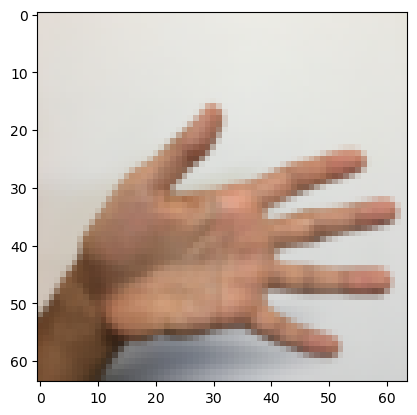

In [21]:
# Example of a picture
index = 0
plt.imshow(X_train_orig[index])
print ("y = " + str(np.squeeze(Y_train_orig[:, index])))

y = 0


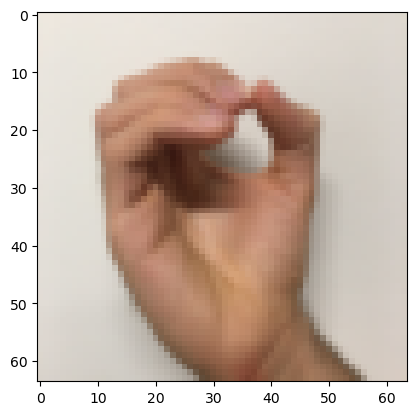

In [23]:
# Example of a picture
index = 1
plt.imshow(X_train_orig[index])
print ("y = " + str(np.squeeze(Y_train_orig[:, index])))

As usual you flatten the image dataset, then normalize it by dividing by 255. On top of that, you will convert each label to a one-hot vector as shown in Figure 1. Run the cell below to do so.

In [ ]:
# Flatten the training and test images into single vectors of features 
X_train_orig.shape

(1080, 64, 64, 3)

In [ ]:
X_test_orig.shape

(120, 64, 64, 3)

In [ ]:
X_train_flatten = X_train_orig.reshape(X_train_orig.shape[0], -1).T
X_test_flatten  = X_test_orig.reshape(X_test_orig.shape[0], -1).T
# Normalize image vectors

In [ ]:
X_train_flatten.shape

(12288, 1080)

In [39]:
X_test_flatten.shape 

(12288, 120)

In [ ]:
X_train = X_train_flatten/255.
X_test  = X_test_flatten/255.
# Convert training and test labels to one hot matrices
Y_train = convert_to_one_hot(Y_train_orig, 6)
Y_test = convert_to_one_hot(Y_test_orig, 6)

In [40]:
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))

X_train shape: (12288, 1080)
Y_train shape: (6, 1080)


In [41]:
print ("number of training examples = " + str(X_train.shape[1]))
print ("number of test examples = " + str(X_test.shape[1]))

number of training examples = 1080
number of test examples = 120


关键要点:
1. X_test[1] 返回单个样本的1D数组
2. X_test[[1]] 返回包含单个样本的2D数组，保持批次维度
3. 在神经网络中，通常使用 X_test[[1]] 来保持数据结构的完整性
4. 这对于批量处理和维度一致性很重要
   
记住: Python 索引从0开始，所以第二列的索引是1。
- 使用 X_test[:, 1] 查看所有样本的第二个特征
- 使用 X_test[:, [1]] 进行神经网络处理（保持维度）
- 使用 X_test[:, 1] 查看所有样本的第二个特征
- 使用 X_test[:, [1]] 进行神经网络处理（保持维度）

In [44]:
print ("X_test sample 1 shape  : " + str(X_test[:,[1]].shape))
print ("Y_test label 1 shape  : " + str(Y_test[:,[1]].shape))


X_test sample 1 shape  : (12288, 1)
Y_test label 1 shape  : (6, 1)


**Note** that 12288 comes from $64 \times 64 \times 3$. Each image is square, 64 by 64 pixels, and 3 is for the RGB colors. Please make sure all these shapes make sense to you before continuing.

**Your goal** is to build an algorithm capable of recognizing a sign with high accuracy. To do so, you are going to build a tensorflow model that is almost the same as one you have previously built in numpy for cat recognition (but now using a softmax output). It is a great occasion to compare your numpy implementation to the tensorflow one. 

**The model** is *LINEAR -> RELU -> LINEAR -> RELU -> LINEAR -> SOFTMAX*. The SIGMOID output layer has been converted to a SOFTMAX. A SOFTMAX layer generalizes SIGMOID to when there are more than two classes. 

### 2.2 - Initializing the parameters

Your second task is to initialize the parameters in tensorflow.

**Exercise:** Implement the function below to initialize the parameters in tensorflow. You are going use Xavier Initialization for weights and Zero Initialization for biases. The shapes are given below. As an example, to help you, for W1 and b1 you could use: 

```python
W1 = tf.get_variable("W1", [25,12288], initializer = tf.contrib.layers.xavier_initializer(seed = 1))
b1 = tf.get_variable("b1", [25,1], initializer = tf.zeros_initializer())
```
Please use `seed = 1` to make sure your results match ours.

In [45]:
def initialize_parameters():
    tf.random.set_seed(1)
    initializer = tf.keras.initializers.GlorotNormal(seed=1)
    parameters = {
        "W1": tf.Variable(initializer(shape=(25, 12288))),
        "b1": tf.Variable(tf.zeros(shape=(25, 1))),
        "W2": tf.Variable(initializer(shape=(12, 25))),
        "b2": tf.Variable(tf.zeros(shape=(12, 1))),
        "W3": tf.Variable(initializer(shape=(6, 12))),
        "b3": tf.Variable(tf.zeros(shape=(6, 1)))
    }
    return parameters

In [46]:
# 修改为：
parameters = initialize_parameters()
print("W1 = " + str(parameters["W1"]))
print("b1 = " + str(parameters["b1"]))
# 不要写 tf.reset_default_graph()，TF2 不需要重置图

W1 = <tf.Variable 'Variable:0' shape=(25, 12288) dtype=float32, numpy=
array([[ 0.00183502, -0.00714326,  0.00914526, ..., -0.01221176,
         0.01656458,  0.00526992],
       [ 0.02264025,  0.0067227 ,  0.00795862, ...,  0.00284724,
         0.01910819,  0.00122853],
       [-0.00163333, -0.00861273, -0.01398893, ..., -0.00741132,
         0.02071251, -0.026417  ],
       ...,
       [-0.00126929,  0.01729332,  0.02082342, ...,  0.01709594,
         0.00429358, -0.00733263],
       [ 0.00275988,  0.00419503,  0.00949959, ...,  0.01241149,
        -0.0270652 ,  0.01501104],
       [-0.00145541,  0.02459595,  0.00339064, ..., -0.02478788,
         0.02716016, -0.00306428]], dtype=float32)>
b1 = <tf.Variable 'Variable:0' shape=(25, 1) dtype=float32, numpy=
array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],

**Expected Output**: 

<table> 
    <tr> 
        <td>
            **W1**
        </td>
        <td>
         < tf.Variable 'W1:0' shape=(25, 12288) dtype=float32_ref >
        </td>
    </tr>
    <tr> 
        <td>
            **b1**
        </td>
        <td>
        < tf.Variable 'b1:0' shape=(25, 1) dtype=float32_ref >
        </td>
    </tr>
    <tr> 
        <td>
            **W2**
        </td>
        <td>
        < tf.Variable 'W2:0' shape=(12, 25) dtype=float32_ref >
        </td>
    </tr>
    <tr> 
        <td>
            **b2**
        </td>
        <td>
        < tf.Variable 'b2:0' shape=(12, 1) dtype=float32_ref >
        </td>
    </tr>

</table>

As expected, the parameters haven't been evaluated yet.

### 2.3 - Forward propagation in tensorflow 

You will now implement the forward propagation module in tensorflow. The function will take in a dictionary of parameters and it will complete the forward pass. The functions you will be using are: 

- `tf.add(...,...)` to do an addition
- `tf.matmul(...,...)` to do a matrix multiplication
- `tf.nn.relu(...)` to apply the ReLU activation

**Question:** Implement the forward pass of the neural network. We commented for you the numpy equivalents so that you can compare the tensorflow implementation to numpy. It is important to note that the forward propagation stops at `z3`. The reason is that in tensorflow the last linear layer output is given as input to the function computing the loss. Therefore, you don't need `a3`!



In [48]:
# GRADED FUNCTION: forward_propagation

def forward_propagation(X, parameters):
    Z1 = tf.add(tf.matmul(parameters['W1'], X), parameters['b1'])
    A1 = tf.nn.relu(Z1)
    Z2 = tf.add(tf.matmul(parameters['W2'], A1), parameters['b2'])
    A2 = tf.nn.relu(Z2)
    Z3 = tf.add(tf.matmul(parameters['W3'], A2), parameters['b3'])
    return Z3
    

In [49]:
X_test = tf.constant(np.random.randn(12288, 6), dtype=tf.float32)
parameters = initialize_parameters()
Z3 = forward_propagation(X_test, parameters)
print("Z3 = " + str(Z3.numpy()))

Z3 = [[-0.9219414   0.3842559  -1.5134648  -0.14066146 -1.1463665  -0.47621524]
 [ 0.6150562  -0.0666487   0.91211015  0.35180372 -0.04978192 -0.28426594]
 [ 0.14837947 -0.07903785 -0.04491404 -0.25341898  0.12733808  0.25911385]
 [-0.55399543  0.45177758 -0.3521629   0.12157166 -0.89494795  0.13007161]
 [ 0.01230851 -0.40200007  0.00202179 -0.34181917  0.18697679 -0.35929373]
 [-0.12920728  0.00554529 -0.6356643   0.15263748  0.5047392   0.28297698]]


You may have noticed that the forward propagation doesn't output any cache. You will understand why below, when we get to brackpropagation.

### 2.4 Compute cost

As seen before, it is very easy to compute the cost using:
```python
tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits = ..., labels = ...))
```
**Question**: Implement the cost function below. 
- It is important to know that the "`logits`" and "`labels`" inputs of `tf.nn.softmax_cross_entropy_with_logits` are expected to be of shape (number of examples, num_classes). We have thus transposed Z3 and Y for you.
- Besides, `tf.reduce_mean` basically does the summation over the examples.

In [50]:
# GRADED FUNCTION: compute_cost 

def compute_cost(Z3, Y):
    """
    Computes the cost
    
    Arguments:
    Z3 -- output of forward propagation (output of the last LINEAR unit), of shape (6, number of examples)
    Y -- "true" labels vector placeholder, same shape as Z3
    
    Returns:
    cost - Tensor of the cost function
    """
    # TF2 需要转置以匹配 (样本, 类别)
    # to fit the tensorflow requirement for tf.nn.softmax_cross_entropy_with_logits(...,...)
    logits = tf.transpose(Z3)
    labels = tf.transpose(Y)
    
    ### START CODE HERE ### (1 line of code)
    cost = tf.reduce_mean(tf.nn.softmax_cross_entropy_with_logits(logits = logits, labels = labels))
    ### END CODE HERE ###
    
    return cost

In [ ]:
# 1. 彻底删除 tf.reset_default_graph()，TF2 不需要重置图
# 2. 彻底删除 tf.Session()，TF2 直接运行函数

# 构造模拟输入数据 (代替原来的 placeholder)
X_test = tf.constant(np.random.randn(12288, 6), dtype=tf.float32)
Y_test = tf.constant(np.random.randn(6, 6), dtype=tf.float32)

# 执行函数
parameters = initialize_parameters()
Z3 = forward_propagation(X_test, parameters)   ## 这里的 forward_propagation  
cost = compute_cost(Z3, Y_test)                ## 这里的 compute_cost

print("cost = " + str(cost.numpy())) # 使用 .numpy() 获取数值

cost = 2.5920367


**Expected Output**: 

<table> 
    <tr> 
        <td>
            **cost**
        </td>
        <td>
        Tensor("Mean:0", shape=(), dtype=float32)
        </td>
    </tr>

</table>

### 2.5 - Backward propagation & parameter updates

This is where you become grateful to programming frameworks. All the backpropagation and the parameters update is taken care of in 1 line of code. It is very easy to incorporate this line in the model.

After you compute the cost function. You will create an "`optimizer`" object. You have to call this object along with the cost when running the tf.session. When called, it will perform an optimization on the given cost with the chosen method and learning rate.

For instance, for gradient descent the optimizer would be:
```python
optimizer = tf.train.GradientDescentOptimizer(learning_rate = learning_rate).minimize(cost)
```

To make the optimization you would do:
```python
_ , c = sess.run([optimizer, cost], feed_dict={X: minibatch_X, Y: minibatch_Y})
```

This computes the backpropagation by passing through the tensorflow graph in the reverse order. From cost to inputs.

**Note** When coding, we often use `_` as a "throwaway" variable to store values that we won't need to use later. Here, `_` takes on the evaluated value of `optimizer`, which we don't need (and `c` takes the value of the `cost` variable). 

### 2.6 - Building the model

Now, you will bring it all together! 

**Exercise:** Implement the model. You will be calling the functions you had previously implemented.

In [ ]:
def model(X_train, Y_train, X_test, Y_test, learning_rate = 0.0001,
          num_epochs = 1500, minibatch_size = 32, print_cost = True):
    
    (n_x, m) = X_train.shape
    n_y = Y_train.shape[0]
    costs = []
    
    # 初始化参数和优化器
    parameters = initialize_parameters()
    optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)
    
    # 预处理数据类型
    X_train = tf.cast(X_train, tf.float32)
    Y_train = tf.cast(Y_train, tf.float32)

    for epoch in range(num_epochs):
        epoch_cost = 0.
        num_minibatches = int(m / minibatch_size)
        minibatches = random_mini_batches(X_train.numpy(), Y_train.numpy(), minibatch_size, seed=epoch)

        for minibatch in minibatches:
            (minibatch_X, minibatch_Y) = minibatch
            
            # 使用 GradientTape 追踪计算过程以计算梯度
            with tf.GradientTape() as tape:
                Z3 = forward_propagation(minibatch_X, parameters)## 前向传播
                minibatch_cost = compute_cost(Z3, minibatch_Y) ## 计算损失 
            
            # 自动获取梯度并更新
            trainable_variables = list(parameters.values()) 
            grads = tape.gradient(minibatch_cost, trainable_variables) ## 计算梯度
            optimizer.apply_gradients(zip(grads, trainable_variables))  ## 更新参数
            
            epoch_cost += minibatch_cost / num_minibatches

        if print_cost and epoch % 100 == 0:
            print(f"Cost after epoch {epoch}: {epoch_cost.numpy():.6f}")
        if print_cost and epoch % 5 == 0:
            costs.append(epoch_cost.numpy())
            
    # 绘图逻辑保持不动
    plt.plot(np.squeeze(costs))
    plt.show()

    return parameters

Run the following cell to train your model! On our machine it takes about 5 minutes. Your "Cost after epoch 100" should be 1.016458. If it's not, don't waste time; interrupt the training by clicking on the square (⬛) in the upper bar of the notebook, and try to correct your code. If it is the correct cost, take a break and come back in 5 minutes!

In [ ]:
parameters = model(X_train, Y_train, X_test, Y_test)

Cost after epoch 0: 1.852534
Cost after epoch 100: 1.019400
Cost after epoch 200: 0.711097
Cost after epoch 300: 0.546127
Cost after epoch 400: 0.436653
Cost after epoch 500: 0.346569
Cost after epoch 600: 0.282607
Cost after epoch 700: 0.220390
Cost after epoch 800: 0.180810
Cost after epoch 900: 0.134936


**Expected Output**:

<table> 
    <tr> 
        <td>
            **Train Accuracy**
        </td>
        <td>
        0.999074
        </td>
    </tr>
    <tr> 
        <td>
            **Test Accuracy**
        </td>
        <td>
        0.716667
        </td>
    </tr>

</table>

Amazing, your algorithm can recognize a sign representing a figure between 0 and 5 with 71.7% accuracy.

**Insights**:
- Your model seems big enough to fit the training set well. However, given the difference between train and test accuracy, you could try to add L2 or dropout regularization to reduce overfitting. 
- Think about the session as a block of code to train the model. Each time you run the session on a minibatch, it trains the parameters. In total you have run the session a large number of times (1500 epochs) until you obtained well trained parameters.

### 2.7 - Test with your own image (optional / ungraded exercise)

Congratulations on finishing this assignment. You can now take a picture of your hand and see the output of your model. To do that:
    1. Click on "File" in the upper bar of this notebook, then click "Open" to go on your Coursera Hub.
    2. Add your image to this Jupyter Notebook's directory, in the "images" folder
    3. Write your image's name in the following code
    4. Run the code and check if the algorithm is right!

In [30]:
def predict_tf2(X, parameters):
    """
    适配 TF2 的预测函数，手动实现原 tf_utils.py 中的逻辑
    """
    # 1. 确保参数是 Tensor 格式
    W1 = tf.convert_to_tensor(parameters["W1"])
    b1 = tf.convert_to_tensor(parameters["b1"])
    W2 = tf.convert_to_tensor(parameters["W2"])
    b2 = tf.convert_to_tensor(parameters["b2"])
    W3 = tf.convert_to_tensor(parameters["W3"])
    b3 = tf.convert_to_tensor(parameters["b3"])
    
    params = {"W1": W1, "b1": b1, "W2": W2, "b2": b2, "W3": W3, "b3": b3}
    
    # 2. 预处理输入数据形状
    x = tf.cast(X, tf.float32)
    
    # 3. 前向传播计算 Z3
    z3 = forward_propagation(x, params)
    
    # 4. 取最大概率索引作为预测类别
    p = tf.argmax(z3)
    
    return p.numpy()

Your algorithm predicts: y = 3


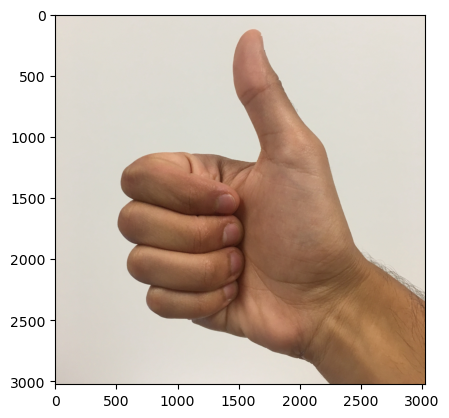

In [31]:
import PIL.Image

## START CODE HERE ## 
my_image = "thumbs_up.jpg" # 确保 images/ 文件夹下有这个文件
## END CODE HERE ##

fname = "images/" + my_image
image = plt.imread(fname)

# 适配 Python 3.10 的缩放处理
img_obj = PIL.Image.fromarray(image)
img_resized = img_obj.resize((64, 64))
my_image_data = np.array(img_resized).reshape((64*64*3, 1)) 

# 归一化
my_image_data = my_image_data / 255.

# 调用刚刚定义好的函数
# 注意：parameters 必须是你之前训练 model() 后返回的那个变量
my_image_prediction = predict_tf2(my_image_data, parameters)

plt.imshow(image)
print("Your algorithm predicts: y = " + str(np.squeeze(my_image_prediction)))

You indeed deserved a "thumbs-up" although as you can see the algorithm seems to classify it incorrectly. The reason is that the training set doesn't contain any "thumbs-up", so the model doesn't know how to deal with it! We call that a "mismatched data distribution" and it is one of the various of the next course on "Structuring Machine Learning Projects".

**What you should remember**:
<font color='cyan'>
- Tensorflow is a programming framework used in deep learning
- The two main object classes in tensorflow are Tensors and Operators. 
- When you code in tensorflow you have to take the following steps:
    - Create a graph containing Tensors (Variables, Placeholders ...) and Operations (tf.matmul, tf.add, ...)
    - Create a session
    - Initialize the session
    - Run the session to execute the graph
- You can execute the graph multiple times as you've seen in model()
- The backpropagation and optimization is automatically done when running the session on the "optimizer" object.